# CellPin Tutorial

CellPin imputes the missing genes of spatially-resolved cells by leveraging a single-cell RNA reference data.  
This notebook walks through three complete workflows:

| Section | Description |
|---------|-------------|
| **A — Standard** | Train on all overlapping genes and impute the full reference gene space |
| **B — Held-out evaluation** | Hold out panel genes before training to benchmark imputation accuracy |

**Before running:** update the file paths in *Load data* cell to point to your own `.h5ad` files.

## Setup

In [1]:
import cellpin
import torch
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

CONFIG_PATH = Path("configs/cellpin_config.yaml")
with CONFIG_PATH.open("r", encoding="utf-8") as f:
    MODEL_CONFIG = yaml.safe_load(f)

## Helper functions

Two evaluation helpers used throughout the notebook:

- `correlation_panel` — mean Pearson correlation between observed and imputed counts for the training panel genes  
- `correlation_heldout` — same metric, but restricted to genes that were **held out** during training (Option B only)

In [2]:
def correlation_panel(adata_imputed, layer_real, layer_imputed):
    """Mean per-gene Pearson r between two layers. Genes with -2 sentinel are excluded."""
    import scipy.sparse as sp

    counts_mat  = adata_imputed.layers[layer_real]
    imputed_mat = adata_imputed.layers[layer_imputed]
    if hasattr(counts_mat,  "toarray"): counts_mat  = counts_mat.toarray()
    if hasattr(imputed_mat, "toarray"): imputed_mat = imputed_mat.toarray()

    valid_idx = np.where(~(counts_mat == -2).any(axis=0))[0]
    pearsons = []
    for j in valid_idx:
        x, y = counts_mat[:, j], imputed_mat[:, j]
        if np.std(x) > 0 and np.std(y) > 0:
            pearsons.append(np.corrcoef(x, y)[0, 1])
        else:
            pearsons.append(np.nan)

    mean_r = np.nanmean(pearsons)
    print(f"Valid genes (no sentinel): {len(valid_idx)}")
    print(f"Mean Pearson r           : {mean_r:.4f}")


def correlation_heldout(adata_imputed, sp_adata_full, heldout_genes,
                        layer_real="counts", layer_imputed="imputed"):
    """Evaluate imputation accuracy on genes held out during training."""
    assert sp_adata_full.n_obs == adata_imputed.n_obs, \
        "Cell count mismatch between sp_adata_full and adata_imputed."

    pearsons = []
    for gene in heldout_genes:
        if gene not in sp_adata_full.var_names or gene not in adata_imputed.var_names:
            print(f"  [{gene}] not found — skipping")
            continue
        real    = sp_adata_full[:, gene].layers[layer_real].toarray().flatten().astype(float)
        imputed = adata_imputed[:, gene].layers[layer_imputed].toarray().flatten().astype(float)
        if np.std(real) == 0 or np.std(imputed) == 0:
            print(f"  [{gene}] zero variance — skipping")
            continue
        r = np.corrcoef(real, imputed)[0, 1]
        pearsons.append(r)
        print(f"  {gene:20s}  Pearson = {r:.4f}")

    mean_r = np.nanmean(pearsons)
    print(f"\nMean Pearson over {len(pearsons)} held-out genes: {mean_r:.4f}")


---
# A) Standard Workflow — Full Panel

The standard CellPin workflow in four steps:

1. Load a single-cell reference (`sc_adata`) and a spatial dataset (`sp_adata`)  
2. Run `cellpin.pp.setup()` to align gene spaces  
3. Train a `CellPin` model on the scRNA reference  
4. Impute the full gene space for every spatial cell  

All overlapping genes between the two datasets are used as panel input.

### A.1 — Load data

Both objects need raw integer counts — either in `.X` or in a named layer (set `LAYER` accordingly).

- `sc_adata`: single-cell reference atlas (full / highly-variable gene space)
- `sp_adata`: spatially-resolved dataset (panel genes only)

**Example data**

- Source dataset: [10x Genomics Xenium breast preview dataset](https://www.10xgenomics.com/products/xenium-in-situ/preview-dataset-human-breast)
- First described in: [Nature Communications (2023)](https://www.nature.com/articles/s41467-023-43458-x)
- Processing: data were processed according to standard single-cell best practices
- scRNA preprocessing: subset to Xenium panel genes plus 1,000 additional highly variable genes
- Spatial data: subsampled, with a normalized layer added
- Samples used:
  - Spatial: *In Situ Sample 1, Replicate 1*
  - Single-cell: *FRP*

In [ ]:
LAYER = "counts"   # layer key with raw integer counts; set to None to use .X

sc_adata = cellpin.pp.load_sc_example()
sp_adata = cellpin.pp.load_sp_example()

print(f"sc_adata : {sc_adata.n_obs:,} cells × {sc_adata.n_vars:,} genes")
print(f"sp_adata : {sp_adata.n_obs:,} cells × {sp_adata.n_vars:,} spatial genes")

sc_adata : 23,867 cells × 1,307 genes
sp_adata : 30,600 cells × 313 spatial genes


### A.2 — Gene alignment check

Confirm which spatial genes are present in the scRNA reference before calling `setup()`.  
Any missing genes will be dropped automatically, but it is good to know upfront.

In [9]:
sc_genes = sc_adata.var_names
sp_genes = sp_adata.var_names

missing = sp_genes.difference(sc_genes)
if len(missing) == 0:
    print(f"All {len(sp_genes)} spatial genes are present in sc_adata ✓")
else:
    print(f"WARNING: {len(missing)} spatial gene(s) not in sc_adata (will be dropped by setup):")
    print(sorted(missing))

overlap = sp_genes.intersection(sc_genes)
print(f"\nPanel size (overlap)        : {len(overlap)} genes")
print(f"scRNA-only genes (to impute): {len(sc_genes) - len(overlap)} genes")

['AKR1C1', 'ANGPT2', 'BTNL9', 'CD8B', 'POLR2J3', 'TPSAB1']

Panel size (overlap)        : 307 genes
scRNA-only genes (to impute): 1000 genes


### A.3 — Setup and train

In [10]:
sc_dataset, sp_dataset = cellpin.pp.setup(sc_adata, sp_adata, layer=LAYER) #add batch_key="batch" if needed -recommended for reference atlases

[cellpin.pp.setup] Setting up CellPin datasets
[cellpin.pp.setup] sc_adata :   23,867 cells  ×    1,307 genes
[cellpin.pp.setup] st_adata :   30,600 cells  ×      313 spatial genes
[cellpin.pp.setup] Expression read from layer='counts'
[cellpin.pp.setup] WARNING: 6 spatial gene(s) not found in sc_adata — will be dropped:
  ['AKR1C1', 'ANGPT2', 'BTNL9', 'CD8B', 'POLR2J3', 'TPSAB1']
[cellpin.pp.setup] Panel    : 307 genes overlap (98.1% of spatial genes retained)
[cellpin.pp.setup] Imputed  : 1,307 genes total in sc space (1,000 genes to impute, not in panel)
[cellpin.pp.setup] sc_dataset: 23,867 cells, 1,307 genes total, 307 panel genes
[cellpin.pp.setup] st_dataset: 30,600 cells, 307 panel genes


In [11]:
model_A = cellpin.CellPin(sc_dataset, config=MODEL_CONFIG)
model_A.fit(sc_dataset, pretrain_epochs=50, train_epochs=60)

Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/home/philipp/miniconda3/envs/cellpin_model/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


/home/philipp/miniconda3/envs/cellpin_model/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Epoch 0:  48%|████▊     | 36/75 [00:02<00:02, 13.11it/s, v_num=4]

Epoch 59: 100%|██████████| 75/75 [00:04<00:00, 16.37it/s, v_num=3, val_loss=514.0, val_reconst_loss=429.0, val_kl_loss=58.80, val_kl_l_loss=2.460, val_distill_loss=0.0748, val_snn_loss=1.450, val_inv_loss=0.198, val_snn_temperature=0.103, val_pearson_loss=0.464, train_loss=519.0, train_reconst_loss=433.0, train_kl_loss=62.00, train_kl_l_loss=2.490, train_distill_loss=0.0953, train_snn_loss=1.680, train_inv_loss=0.238, train_snn_temperature=0.103, train_pearson_loss=0.434]


### A.4 — Impute

`return_norm=True` adds an area-normalised log1p layer (`imputed_norm`).  
Set `area_key=None` if your spatial data has no `cell_area` column.

In [12]:
dl_A = torch.utils.data.DataLoader(sp_dataset, batch_size=512, shuffle=False)

adata_imputed_A = model_A.impute(
    dl_A,
    obs_adata=sp_adata,
    return_norm=True,
    area_key="cell_area",
    nb_count_samples=20,
)
print(adata_imputed_A)

Embedding and imputing cells (MC, 50 samples)...
[CellPin.impute] Panel gene order confirmed ✓
  [impute] Filling 1000 gene(s) absent from obs_adata layers with sentinel -2.0
  [impute] Filling 1000 gene(s) absent from obs_adata layers with sentinel -2.0
AnnData object with n_obs × n_vars = 30600 × 1307
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region'
    obsm: 'X_cellpin', 'spatial'
    layers: 'counts', 'log1p_norm', 'imputed', 'imputed_norm'


### A.5 — Evaluate

Pearson correlation between observed and imputed counts for panel genes.

In [13]:
print("=== Count space ===")
correlation_panel(adata_imputed_A, layer_real="counts", layer_imputed="imputed")

print("\n=== Log-normalised space ===")
correlation_panel(adata_imputed_A, layer_real="log1p_norm", layer_imputed="imputed_norm")

=== Count space ===
Valid genes (no sentinel): 307
Mean Pearson r           : 0.5999

=== Log-normalised space ===
Valid genes (no sentinel): 307
Mean Pearson r           : 0.5018


### A.6 — Visualise

Spatial maps and UMAP for a few marker genes.  
`MS4A1` and `CD19` were in the panel; `FCRL1` and `PAX5` are purely imputed. (All B cell genes, expected to co-localise)

/tmp/ipykernel_4125212/4247071269.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_imputed_A, layer="imputed_norm", color=GENE,


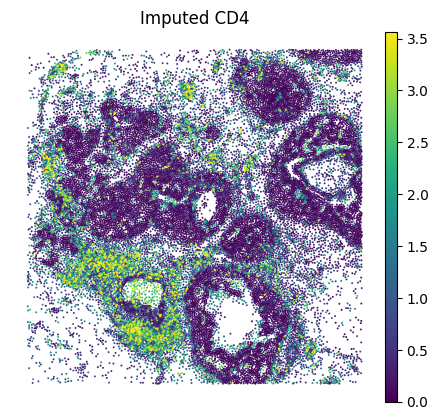

/tmp/ipykernel_4125212/4247071269.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_imputed_A, layer="log1p_norm",   color=GENE,


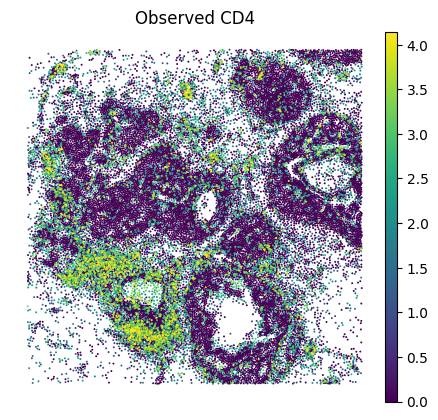

In [14]:
GENE = "CD4"   # edit as needed

sc.pl.spatial(adata_imputed_A, layer="imputed_norm", color=GENE,
              spot_size=15, vmax="p99", frameon=False, title=f"Imputed {GENE}")
sc.pl.spatial(adata_imputed_A, layer="log1p_norm",   color=GENE,
              spot_size=15, vmax="p99", frameon=False, title=f"Observed {GENE}")

Spatial plots — B-cell markers:


/tmp/ipykernel_4125212/1331889655.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_imputed_A, layer="imputed_norm", color=bcells,


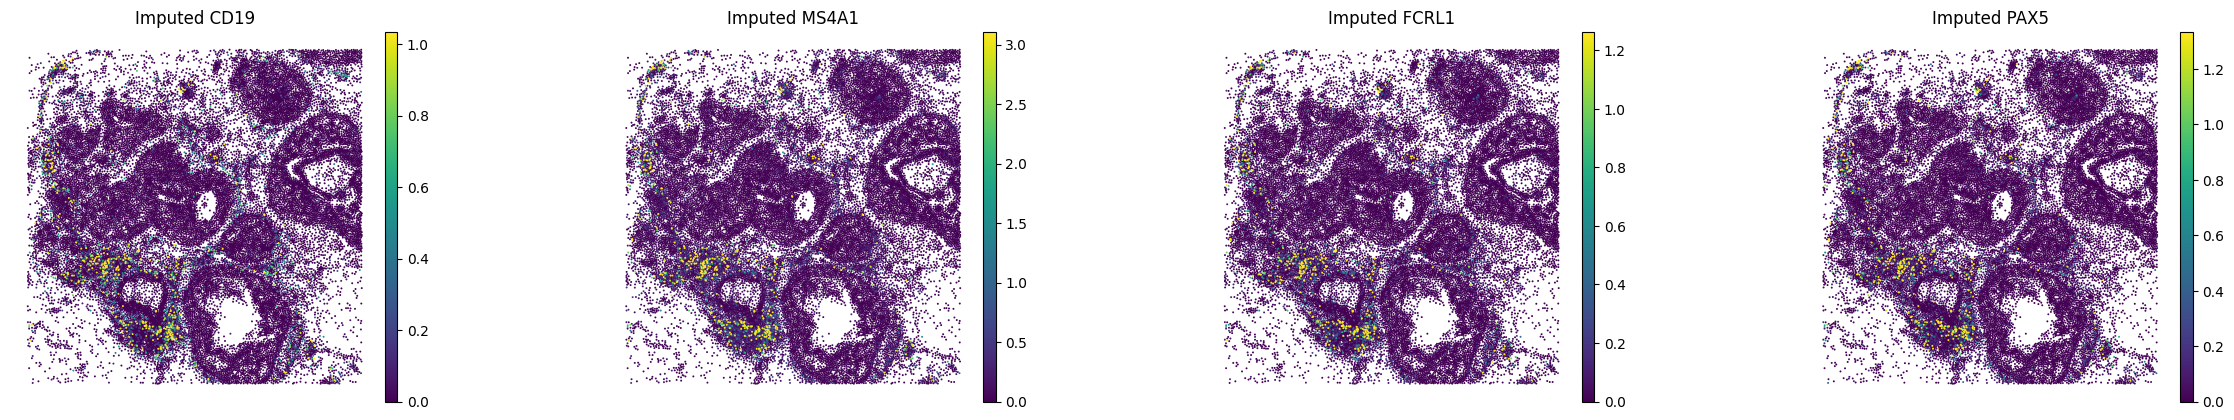

/tmp/ipykernel_4125212/1331889655.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_imputed_A, layer="log1p_norm",   color=bcells,


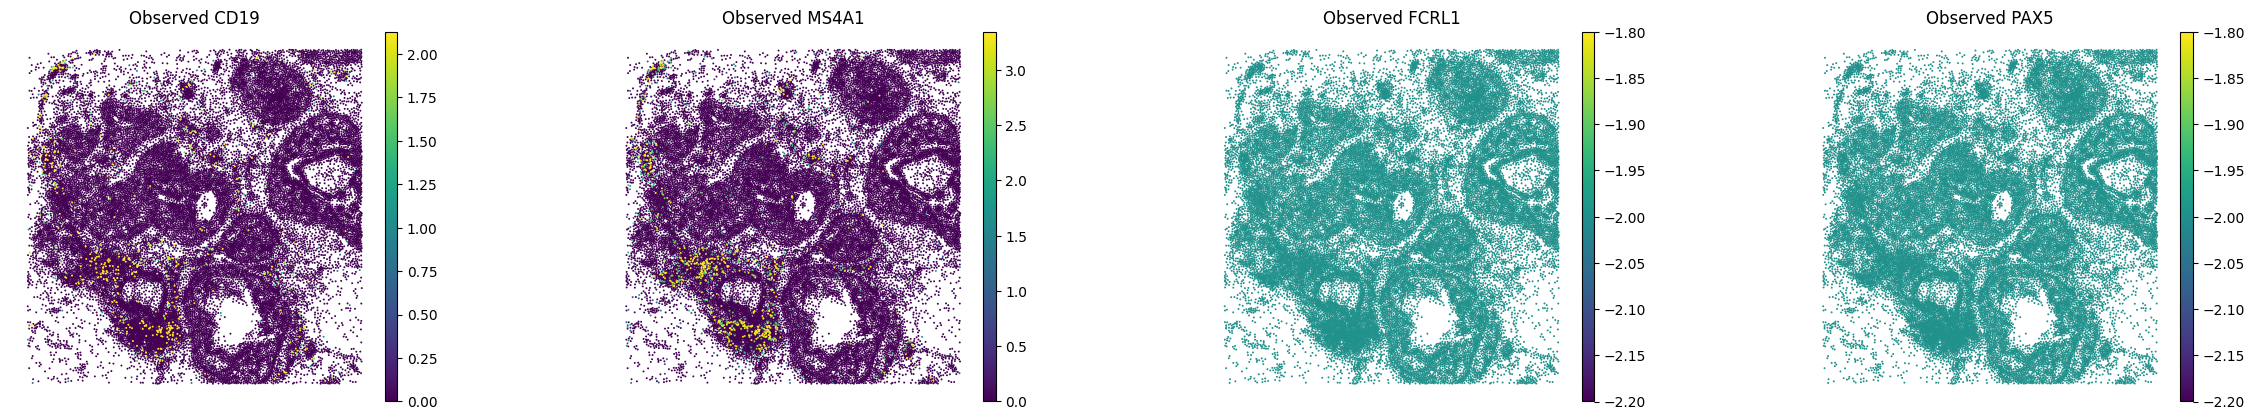

In [15]:
bcells = ["CD19", "MS4A1", "FCRL1", "PAX5"]

print("Spatial plots — B-cell markers:")
sc.pl.spatial(adata_imputed_A, layer="imputed_norm", color=bcells,
              spot_size=15, vmax="p99", frameon=False, title=[f"Imputed {g}" for g in bcells])
sc.pl.spatial(adata_imputed_A, layer="log1p_norm",   color=bcells,
              spot_size=15, vmax="p99", frameon=False, title=[f"Observed {g}" for g in bcells])

### A.7 — UMAP from CellPin embeddings

Cell embeddings in `obsm["X_cellpin"]` can be used directly to build a neighborhood graph and compute a UMAP

/home/philipp/miniconda3/envs/cellpin_model/lib/python3.11/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


UMAP — B-cell markers:


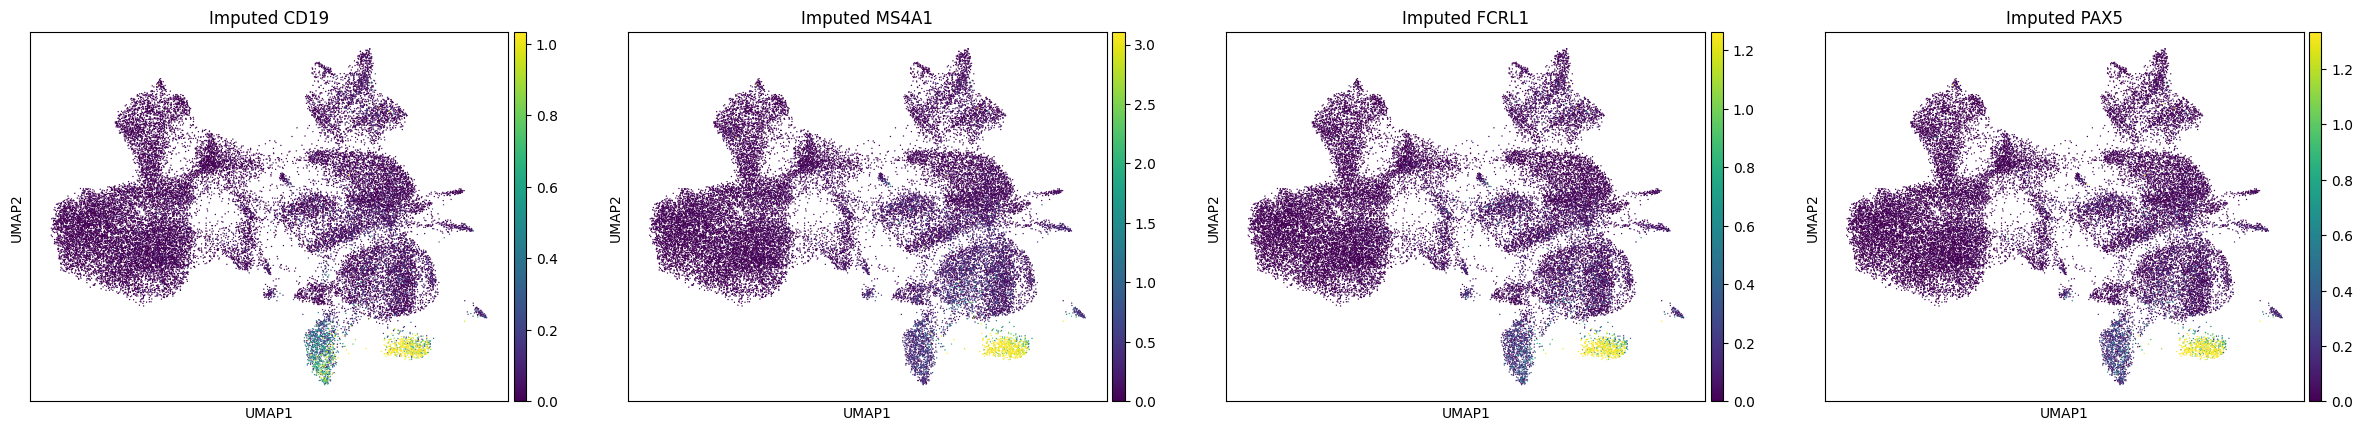

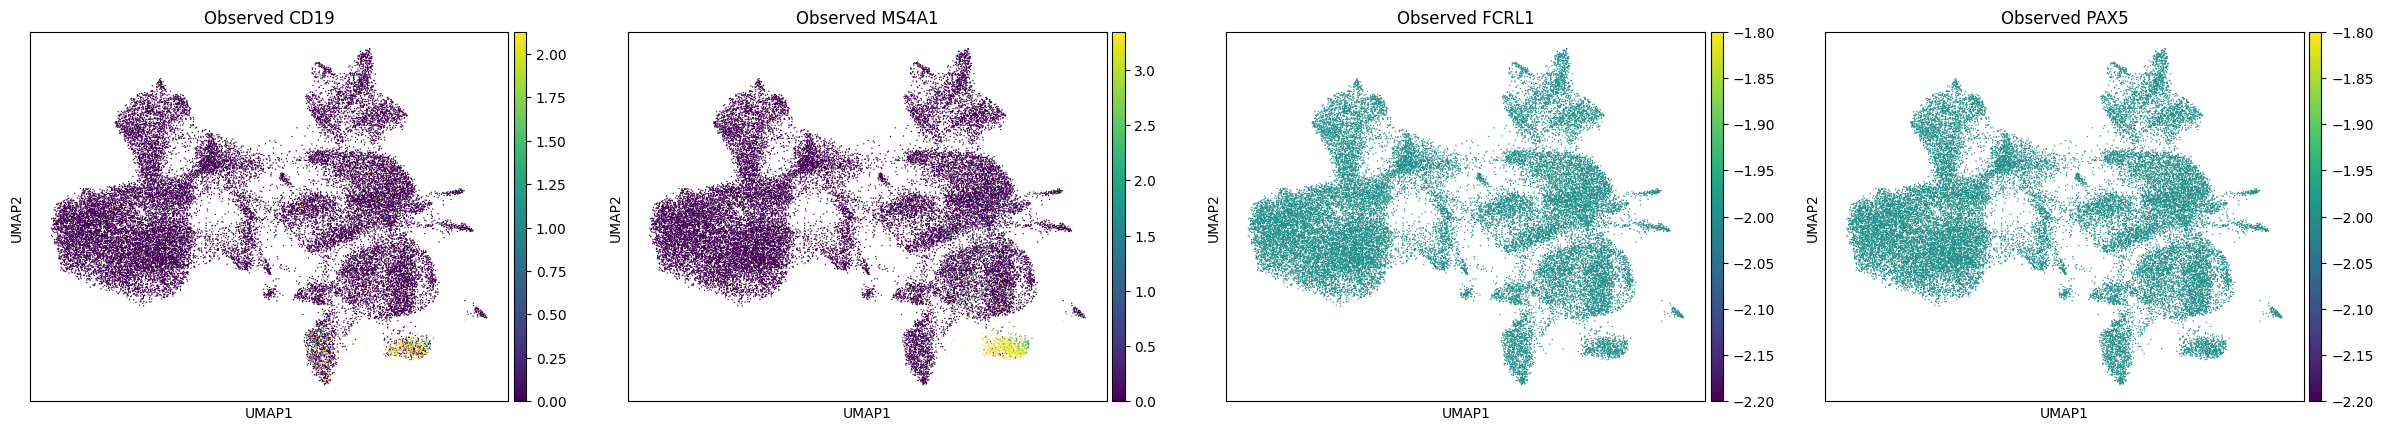

In [16]:
sc.pp.neighbors(adata_imputed_A, use_rep="X_cellpin")
sc.tl.umap(adata_imputed_A)

print("UMAP — B-cell markers:")
sc.pl.umap(adata_imputed_A, color=bcells, layer="imputed_norm", vmax="p99",
           title=[f"Imputed {g}" for g in bcells])
sc.pl.umap(adata_imputed_A, color=bcells, layer="log1p_norm",   vmax="p99",
           title=[f"Observed {g}" for g in bcells])

---
# B) Held-Out Gene Evaluation

To benchmark how well CellPin imputes genes it has never seen during training, we:

1. Randomly sample a fraction of panel genes as **held-out genes**  
2. Remove them from the spatial input before `setup()`  
3. Train and impute as normal  
4. Compare imputed values against the ground-truth counts for those held-out genes  

The held-out Pearson correlation is the most honest imputation benchmark.

### B.1 — Define held-out genes

In [17]:
rng = np.random.default_rng(42)

# Panel genes in sc_adata order — consistent with setup()'s internal ordering
panel_genes_all = [g for g in sc_adata.var_names if g in set(sp_adata.var_names)]
print(f"Full panel size: {len(panel_genes_all)} genes")

HOLDOUT_FRACTION = 0.10   # hold out 10 % of the panel
n_holdout     = max(1, int(len(panel_genes_all) * HOLDOUT_FRACTION))
heldout_genes = rng.choice(panel_genes_all, size=n_holdout, replace=False).tolist()
training_genes = [g for g in panel_genes_all if g not in heldout_genes]

print(f"Held-out genes : {n_holdout}  → {heldout_genes[:5]} ...")
print(f"Training panel : {len(training_genes)} genes")

Full panel size: 307 genes
Held-out genes : 30  → ['NDUFA4L2', 'CCDC6', 'LEP', 'CCL8', 'ELF3'] ...
Training panel : 277 genes


In [18]:
# Build the reduced spatial object (held-out genes removed)
sp_adata_reduced = sp_adata[:, training_genes].copy()

assert len(set(heldout_genes) & set(sp_adata_reduced.var_names)) == 0, \
    "Held-out genes still present in reduced sp_adata!"
print(f"sp_adata_reduced: {sp_adata_reduced.n_obs:,} cells × {sp_adata_reduced.n_vars:,} genes (held-out genes removed ✓)")

sp_adata_reduced: 30,600 cells × 277 genes (held-out genes removed ✓)


### B.2 — Setup and train

In [19]:
sc_dataset_B, sp_dataset_B = cellpin.pp.setup(sc_adata, sp_adata_reduced, layer=LAYER)

[cellpin.pp.setup] Setting up CellPin datasets
[cellpin.pp.setup] sc_adata :   23,867 cells  ×    1,307 genes
[cellpin.pp.setup] st_adata :   30,600 cells  ×      277 spatial genes
[cellpin.pp.setup] Expression read from layer='counts'
[cellpin.pp.setup] Panel    : 277 genes overlap (100.0% of spatial genes retained)
[cellpin.pp.setup] Imputed  : 1,307 genes total in sc space (1,030 genes to impute, not in panel)
[cellpin.pp.setup] sc_dataset: 23,867 cells, 1,307 genes total, 277 panel genes
[cellpin.pp.setup] st_dataset: 30,600 cells, 277 panel genes


In [20]:
model_B = cellpin.CellPin(sc_dataset_B, config=MODEL_CONFIG)
model_B.fit(sc_dataset_B, pretrain_epochs=50, train_epochs=60)

/home/philipp/miniconda3/envs/cellpin_model/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
/home/philipp/miniconda3/envs/cellpin_model/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Epoch 0:   7%|▋         | 5/75 [00:00<00:05, 13.22it/s, v_num=5]

Epoch 59: 100%|██████████| 75/75 [00:08<00:00,  8.97it/s, v_num=4, val_loss=515.0, val_reconst_loss=430.0, val_kl_loss=61.60, val_kl_l_loss=2.480, val_distill_loss=0.0838, val_snn_loss=1.560, val_inv_loss=0.216, val_snn_temperature=0.104, val_pearson_loss=0.467, train_loss=521.0, train_reconst_loss=434.0, train_kl_loss=64.10, train_kl_l_loss=2.530, train_distill_loss=0.104, train_snn_loss=1.790, train_inv_loss=0.256, train_snn_temperature=0.104, train_pearson_loss=0.439] 


### B.3 — Impute

In [21]:
dl_B = torch.utils.data.DataLoader(sp_dataset_B, batch_size=512, shuffle=False)

adata_imputed_B = model_B.impute(
    dl_B,
    obs_adata=sp_adata_reduced,
    return_norm=True,
    area_key="cell_area",
    nb_count_samples=20,
)
print(adata_imputed_B)

Embedding and imputing cells (MC, 50 samples)...
[CellPin.impute] Panel gene order confirmed ✓
  [impute] Filling 1030 gene(s) absent from obs_adata layers with sentinel -2.0
  [impute] Filling 1030 gene(s) absent from obs_adata layers with sentinel -2.0


AnnData object with n_obs × n_vars = 30600 × 1307
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region'
    obsm: 'X_cellpin', 'spatial'
    layers: 'counts', 'log1p_norm', 'imputed', 'imputed_norm'


### B.4 — Evaluate

Two metrics:
- **Panel Pearson** — reconstruction quality on the training genes (sanity check)  
- **Held-out Pearson** — true imputation benchmark on genes the model never saw

In [22]:
print("=== Training panel genes (count space) ===")
correlation_panel(adata_imputed_B, layer_real="counts", layer_imputed="imputed")

=== Training panel genes (count space) ===
Valid genes (no sentinel): 277
Mean Pearson r           : 0.6055


In [23]:
print("=== Held-out genes — count space ===")
correlation_heldout(
    adata_imputed_B,
    sp_adata_full=sp_adata,          # sp_adata (full) has ground-truth counts for held-out genes
    heldout_genes=heldout_genes,
    layer_real="counts",
    layer_imputed="imputed",
)

=== Held-out genes — count space ===
  NDUFA4L2              Pearson = 0.1890
  CCDC6                 Pearson = 0.6152
  LEP                   Pearson = 0.3459
  CCL8                  Pearson = 0.1911
  ELF3                  Pearson = 0.6601
  ENAH                  Pearson = 0.4541


  TIMP4                 Pearson = 0.3194
  KRT14                 Pearson = 0.8093
  ITGAX                 Pearson = 0.7586
  LYZ                   Pearson = 0.7732
  GNLY                  Pearson = 0.5472
  CX3CR1                Pearson = 0.4707
  SPIB                  Pearson = 0.4015
  CXCL12                Pearson = 0.8331
  KRT23                 Pearson = 0.8330
  DNAAF1                Pearson = 0.0590
  AGR3                  Pearson = 0.6214
  FOXA1                 Pearson = 0.8634
  FOXP3                 Pearson = 0.3166
  PTN                   Pearson = 0.7785
  PDCD1LG2              Pearson = 0.2293
  CCND1                 Pearson = 0.7897
  SQLE                  Pearson = 0.4613
  ANKRD30A              Pearson = 0.8595
  SERPINA3              Pearson = 0.7529
  CEACAM8               Pearson = -0.0063
  GPR183                Pearson = 0.5357
  CLECL1                Pearson = 0.2631
  LILRA4                Pearson = 0.7573
  CCPG1                 Pearson = 0.4568

Mean Pearson o

In [24]:
print("=== Held-out genes — log-normalised space ===")
correlation_heldout(
    adata_imputed_B,
    sp_adata_full=sp_adata,
    heldout_genes=heldout_genes,
    layer_real="log1p_norm",
    layer_imputed="imputed_norm",
)

=== Held-out genes — log-normalised space ===
  NDUFA4L2              Pearson = 0.1649
  CCDC6                 Pearson = 0.5151
  LEP                   Pearson = 0.1456
  CCL8                  Pearson = 0.1481
  ELF3                  Pearson = 0.6516
  ENAH                  Pearson = 0.3642
  TIMP4                 Pearson = 0.0989
  KRT14                 Pearson = 0.7434
  ITGAX                 Pearson = 0.5881
  LYZ                   Pearson = 0.6634
  GNLY                  Pearson = 0.4140
  CX3CR1                Pearson = 0.3982
  SPIB                  Pearson = 0.3594
  CXCL12                Pearson = 0.7600
  KRT23                 Pearson = 0.7265
  DNAAF1                Pearson = 0.0539
  AGR3                  Pearson = 0.5707
  FOXA1                 Pearson = 0.8420
  FOXP3                 Pearson = 0.2787
  PTN                   Pearson = 0.7094
  PDCD1LG2              Pearson = 0.1527
  CCND1                 Pearson = 0.6899
  SQLE                  Pearson = 0.3210
  ANKRD30A 

### B.5 — Visualise held-out genes

Compare imputed vs. observed spatial expression for a few held-out genes with strong Pearson correlation.

/tmp/ipykernel_4125212/3482941651.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_imputed_B, layer="imputed_norm", color=GENES_HELDOUT,


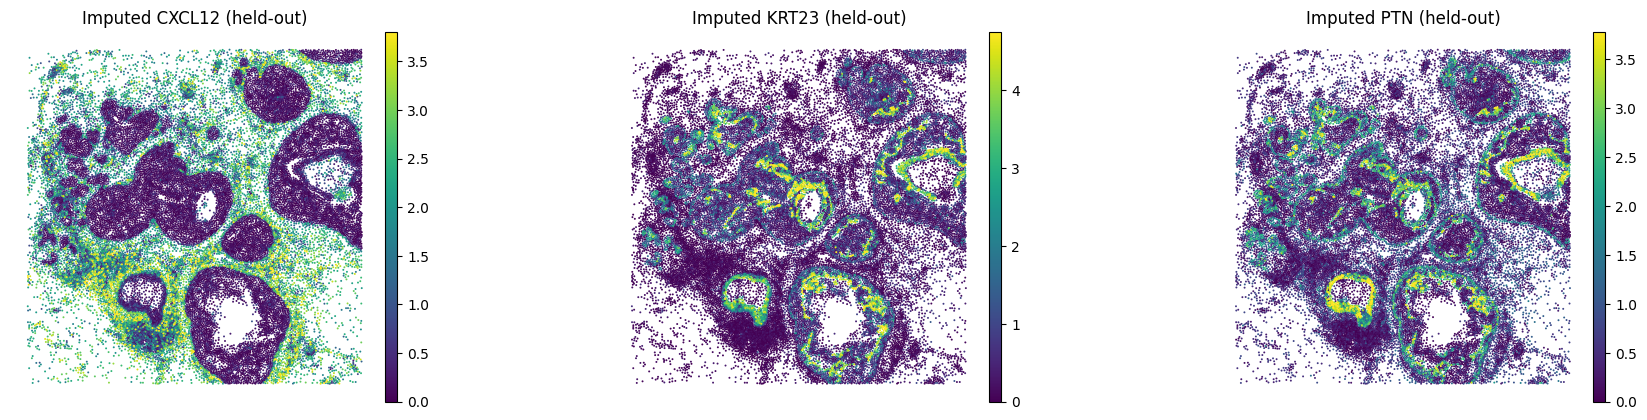

/tmp/ipykernel_4125212/3482941651.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sp_adata, layer="log1p_norm", color=GENES_HELDOUT,


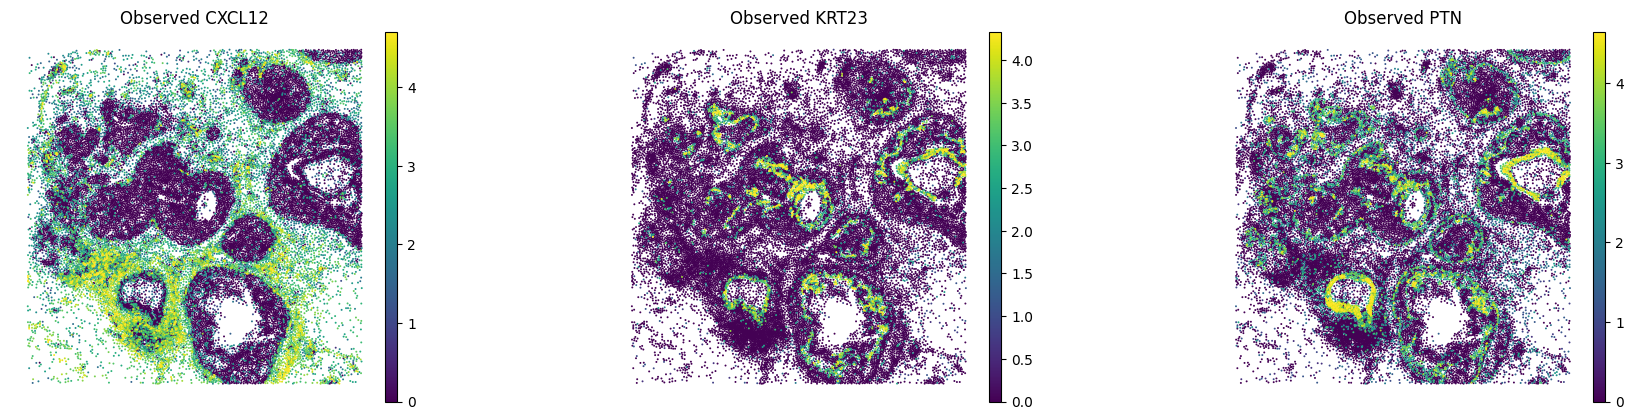

In [25]:
# Edit: pick held-out genes with high Pearson from the evaluation above
GENES_HELDOUT = ["CXCL12", "KRT23", "PTN"]

sc.pl.spatial(adata_imputed_B, layer="imputed_norm", color=GENES_HELDOUT,
              spot_size=15, vmax="p99", frameon=False,
              title=[f"Imputed {g} (held-out)" for g in GENES_HELDOUT])
sc.pl.spatial(sp_adata, layer="log1p_norm", color=GENES_HELDOUT,
              spot_size=15, vmax="p99", frameon=False,
              title=[f"Observed {g}" for g in GENES_HELDOUT])